In [5]:
from transformers_sae.ops import load_checkpoint

loss_history = {}
min_layer = 0
max_layer = 2
# num_tokens = 10000585
# num_tokens = 5001006
# num_tokens = 2000682
num_tokens = 1000660
variant = "_tmse"
for layer in range(min_layer, max_layer + 1):
    loss_history[layer] = load_checkpoint(
        f"/workspace/sae_checkpoints/gemma_2_2b/next_layer_lista_onsager_tuned_encoder_0{variant}/layer_{layer}_tokens_{num_tokens}.checkpoint",
    ).step_metrics

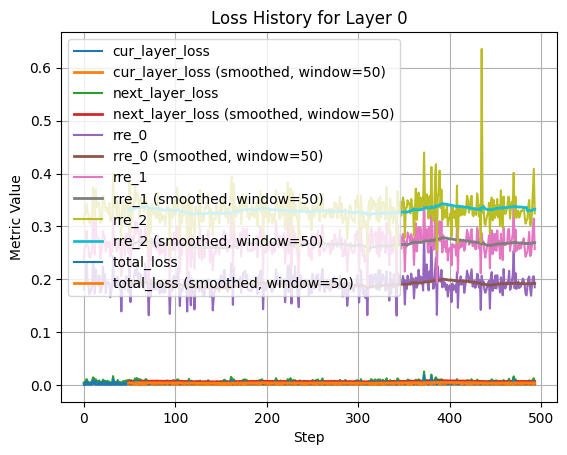

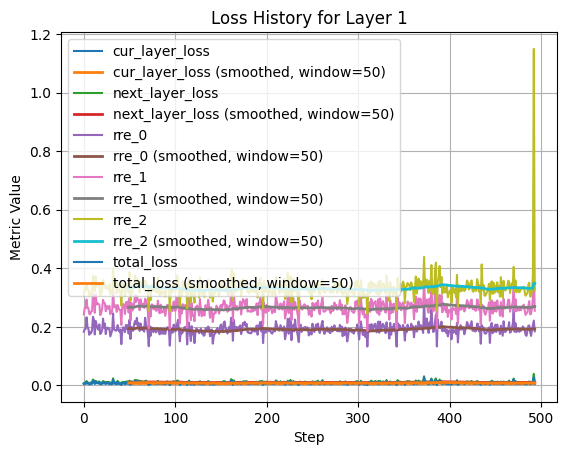

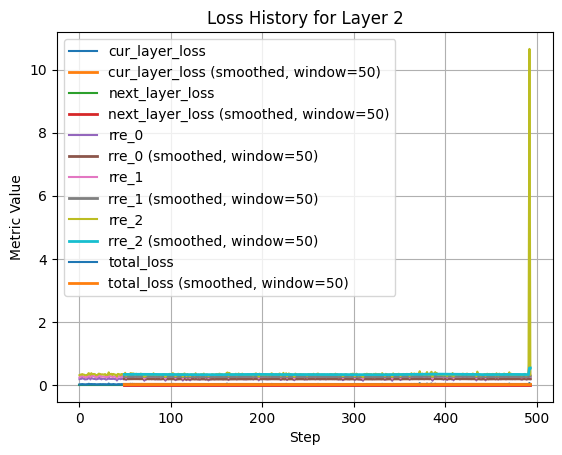

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_losses_for_layer(layer, metric_dict, window_size=50, key_filter=None):
    """
    Plots all metrics for a single layer.

    layer: layer number (int)
    metric_dict: dict[metric] -> list[float]
    window_size: window size for smoothing curves
    """
    plt.figure()
    for metric, losses in metric_dict.items():
        if key_filter is not None and not key_filter(metric):
            continue
        losses = np.array(losses)
        plt.plot(losses, label=f"{metric}")

        if len(losses) >= window_size:
            # Moving average smoothing
            smoothed = np.convolve(
                losses, np.ones(window_size) / window_size, mode="valid"
            )
            plt.plot(
                np.arange(window_size - 1, len(losses)),
                smoothed,
                label=f"{metric} (smoothed, window={window_size})",
                linewidth=2,
            )

    plt.title(f"Loss History for Layer {layer}")
    plt.xlabel("Step")
    plt.ylabel("Metric Value")
    plt.grid(True)
    plt.legend()
    plt.show()


# Now plot for all layers in the dict
for layer, metric_dict in loss_history.items():
    plot_losses_for_layer(layer, metric_dict, window_size=50, key_filter=lambda k: k.startswith("rre"))

# From scratch

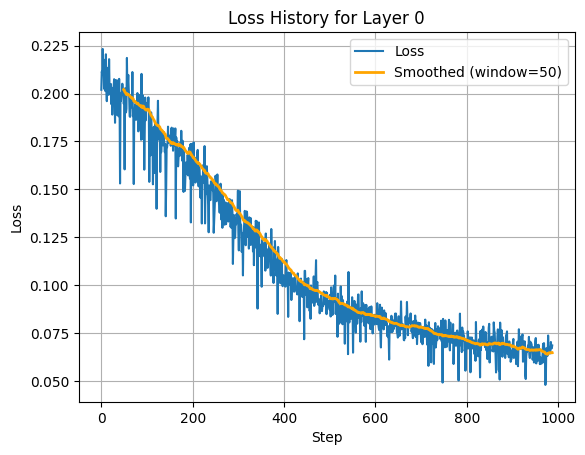

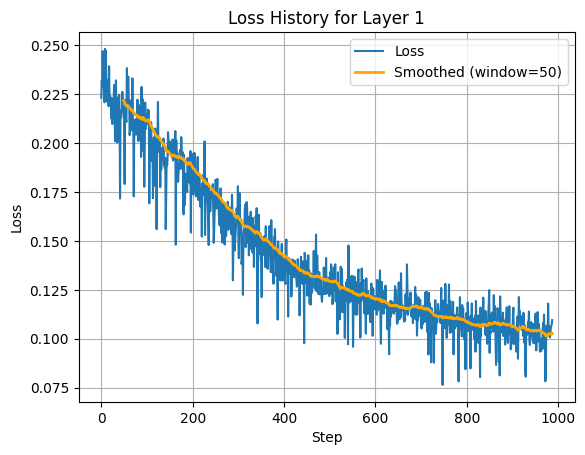

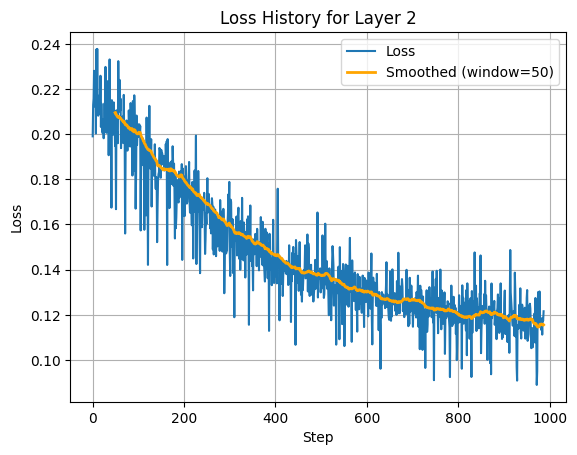

In [2]:
import matplotlib.pyplot as plt
import numpy as np

window_size = 50  # set the window size for smoothing, tweak as preferred

for layer, losses in loss_history.items():
    plt.figure()
    plt.plot(losses, label="Loss")

    if len(losses) >= window_size:
        # Compute moving average
        smoothed = np.convolve(losses, np.ones(window_size)/window_size, mode='valid')
        plt.plot(
            np.arange(window_size - 1, len(losses)),
            smoothed,
            label=f"Smoothed (window={window_size})",
            color="orange",
            linewidth=2,
        )

    plt.title(f"Loss History for Layer {layer}")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()